<a href="https://colab.research.google.com/github/yentran31251022363-ship-it/HW---Tran-Hai-Yen/blob/main/HW_week_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

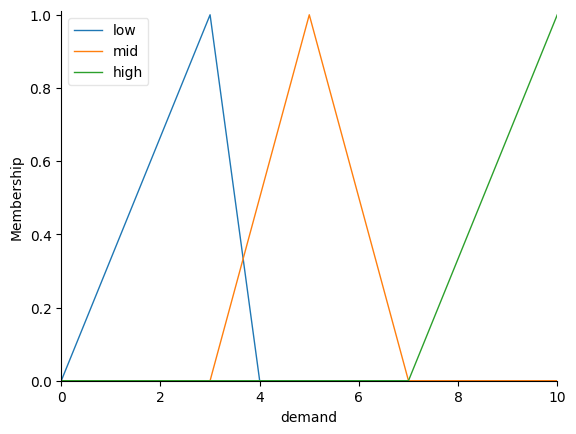

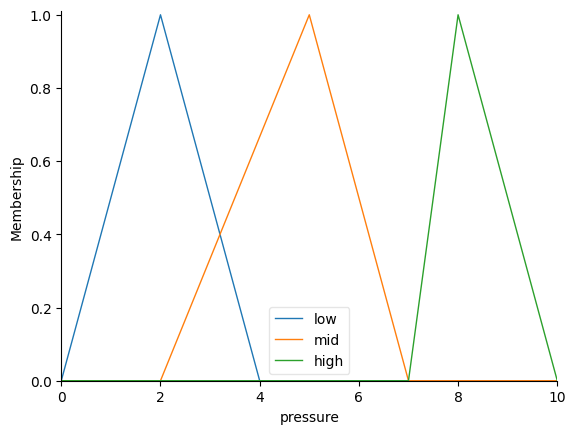

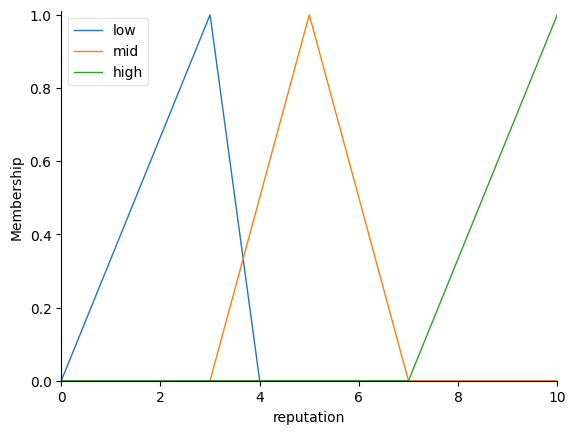

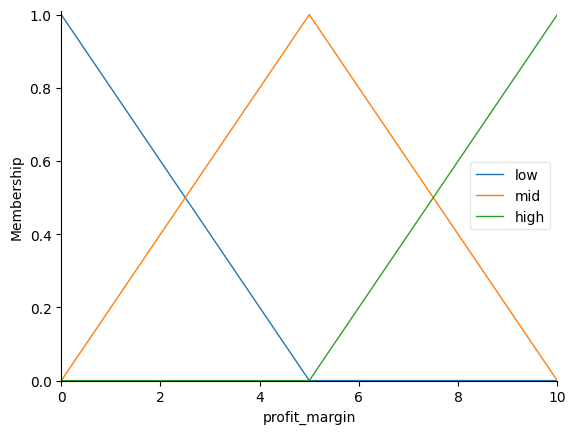

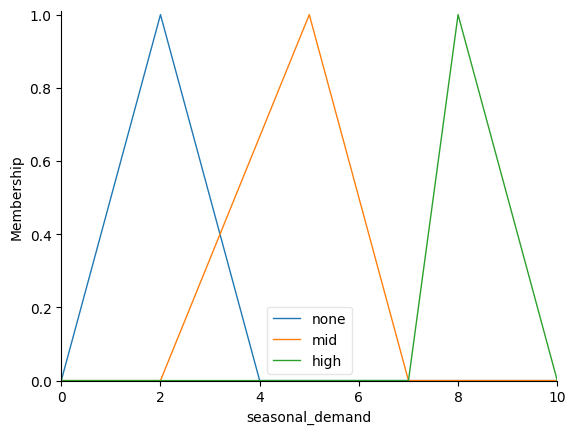

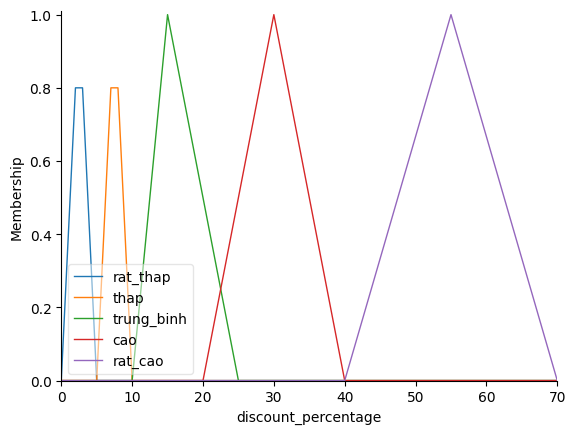

In [ ]:
#2.13
!pip install scikit-fuzzy
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

demand = ctrl.Antecedent(np.arange(0, 11, 1), 'demand')
pressure = ctrl.Antecedent(np.arange(0, 11, 1), 'pressure')
reputation = ctrl.Antecedent(np.arange(0, 11, 1), 'reputation')
profit_margin = ctrl.Antecedent(np.arange(0, 11, 1), 'profit_margin')
seasonal_demand = ctrl.Antecedent(np.arange(0, 11, 1), 'seasonal_demand')
discount_percentage = ctrl.Consequent(np.arange(0, 71, 1), 'discount_percentage')

demand['low'] = fuzz.trimf(demand.universe, [0, 3, 3])
demand['mid'] = fuzz.trimf(demand.universe, [3,5,7])
demand['high'] = fuzz.trimf(demand.universe, [7,10,10])

pressure['low'] = fuzz.trimf(pressure.universe, [0,2,4])
pressure['mid'] = fuzz.trimf(pressure.universe, [2,5,7])
pressure['high'] = fuzz.trimf(pressure.universe, [7,8,10])

reputation['low'] = fuzz.trimf(reputation.universe, [0, 3, 3])
reputation['mid'] = fuzz.trimf(reputation.universe, [3,5,7])
reputation['high'] = fuzz.trimf(reputation.universe, [7,10,10])

profit_margin['low'] = fuzz.trimf(profit_margin.universe, [0, 0, 5])
profit_margin['mid'] = fuzz.trimf(profit_margin.universe, [0, 5, 10])
profit_margin['high'] = fuzz.trimf(profit_margin.universe, [5, 10, 10])

seasonal_demand['none'] = fuzz.trimf(seasonal_demand.universe, [0,2,4])
seasonal_demand['mid'] = fuzz.trimf(seasonal_demand.universe, [2,5,7])
seasonal_demand['high'] = fuzz.trimf(seasonal_demand.universe, [7,8,10])

discount_percentage['rat_thap'] = fuzz.trimf(discount_percentage.universe, [0, 2.5, 5])
discount_percentage['thap'] = fuzz.trimf(discount_percentage.universe, [5, 7.5, 10])
discount_percentage['trung_binh'] = fuzz.trimf(discount_percentage.universe, [10, 15, 25])
discount_percentage['cao'] = fuzz.trimf(discount_percentage.universe, [20, 30, 40])
discount_percentage['rat_cao'] = fuzz.trimf(discount_percentage.universe, [40, 55, 70])

demand.view()
pressure.view()
reputation.view()
profit_margin.view()
seasonal_demand.view()
discount_percentage.view()


Mức chiết khấu đề xuất: 17.26%


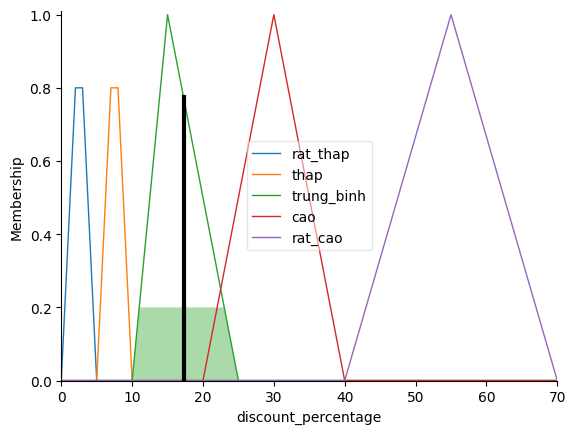

In [ ]:
rule1 = ctrl.Rule(demand['high'] & pressure['low'] & profit_margin['low'], discount_percentage['rat_thap'])
rule2 = ctrl.Rule(demand['low'] & pressure['high'] & profit_margin['high'], discount_percentage['cao'])
rule3 = ctrl.Rule(reputation['high'] & profit_margin['mid'] & seasonal_demand['high'], discount_percentage['trung_binh'])
rule4 = ctrl.Rule(pressure['high'] & seasonal_demand['high'] & profit_margin['high'], discount_percentage['rat_cao'])
rule5 = ctrl.Rule(reputation['low'] & demand['mid'] & profit_margin['low'], discount_percentage['trung_binh'])
rule6 = ctrl.Rule(demand['high'] & seasonal_demand['none'] & pressure['low'], discount_percentage['rat_thap'])
rule7 = ctrl.Rule(profit_margin['high'] & pressure['mid'] & seasonal_demand['mid'], discount_percentage['trung_binh'])

discount_percentage_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
simulation = ctrl.ControlSystemSimulation(discount_percentage_ctrl)

simulation.input['demand'] = 9
simulation.input['pressure'] = 5
simulation.input['reputation'] = 8
simulation.input['profit_margin'] = 9
simulation.input['seasonal_demand'] = 8


simulation.compute()

print(f"Mức chiết khấu đề xuất: {simulation.output['discount_percentage']:.2f}%")
discount_percentage.view(sim=simulation)

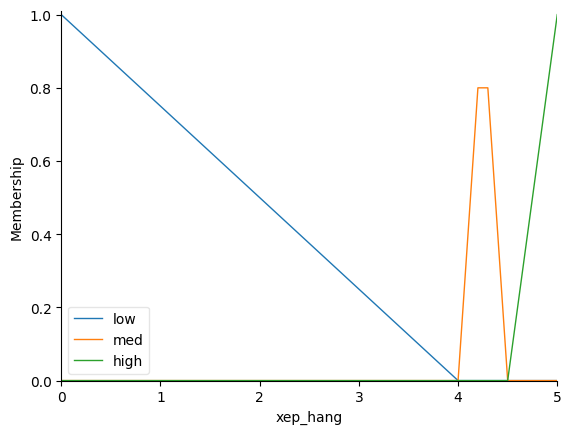

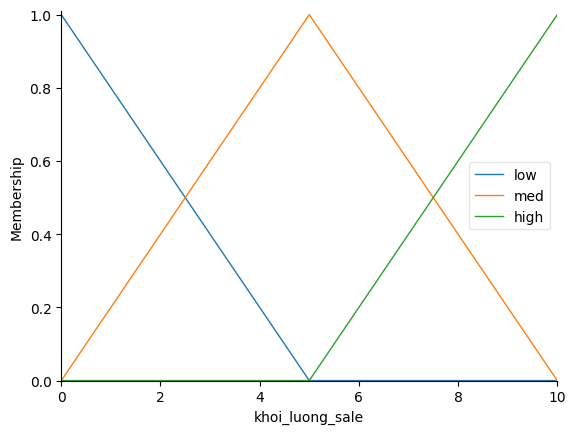

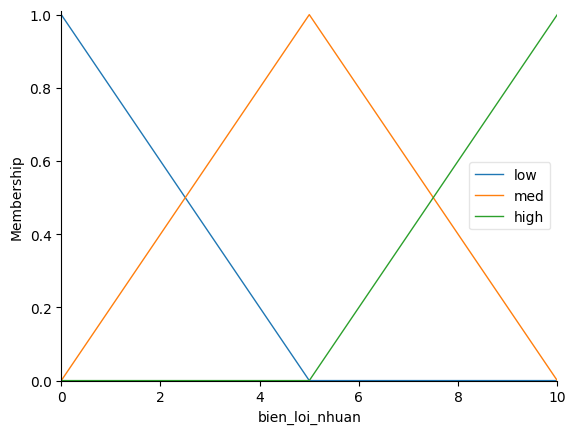

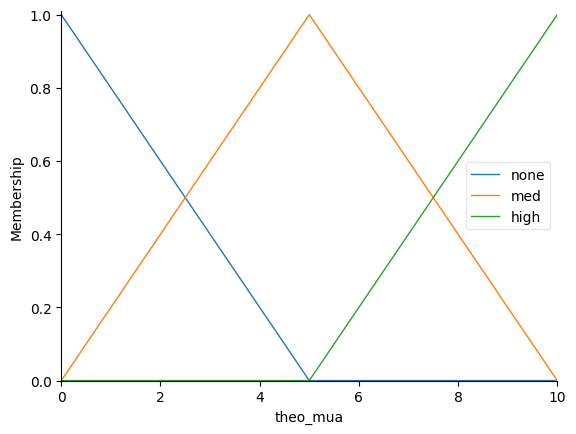

In [ ]:
#2.12
!pip install scikit-fuzzy
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

xep_hang = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'xep_hang')
khoi_luong_sale = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'khoi_luong_sale')
bien_loi_nhuan = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'bien_loi_nhuan')
theo_mua = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'theo_mua')
doi_thu = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'doi_thu')
chiet_khau = ctrl.Consequent(np.arange(0, 71, 1), 'chiet_khau')

xep_hang['low'] = fuzz.trimf(xep_hang.universe, [0, 0, 4.0])
xep_hang['med'] = fuzz.trimf(xep_hang.universe, [4.0, 4.25, 4.5])
xep_hang['high'] = fuzz.trimf(xep_hang.universe, [4.5, 5.0, 5.0])

for var in [khoi_luong_sale, bien_loi_nhuan, doi_thu]:
    var['low'] = fuzz.trimf(var.universe, [0, 0, 5])
    var['med'] = fuzz.trimf(var.universe, [0, 5, 10])
    var['high'] = fuzz.trimf(var.universe, [5, 10, 10])

theo_mua['none'] = fuzz.trimf(theo_mua.universe, [0, 0, 5])
theo_mua['med'] = fuzz.trimf(theo_mua.universe, [0, 5, 10])
theo_mua['high'] = fuzz.trimf(theo_mua.universe, [5, 10, 10])

chiet_khau['rat_thap'] = fuzz.trimf(chiet_khau.universe, [0, 2.5, 5])
chiet_khau['thap'] = fuzz.trimf(chiet_khau.universe, [5, 7.5, 10])
chiet_khau['trung_binh'] = fuzz.trimf(chiet_khau.universe, [10, 15, 20])
chiet_khau['cao'] = fuzz.trimf(chiet_khau.universe, [20, 30, 40])
chiet_khau['rat_cao'] = fuzz.trimf(chiet_khau.universe, [40, 55, 70])

xep_hang.view()
khoi_luong_sale.view()
bien_loi_nhuan.view()
theo_mua.view()


Mức chiết khấu đề xuất từ AI: 42.00%


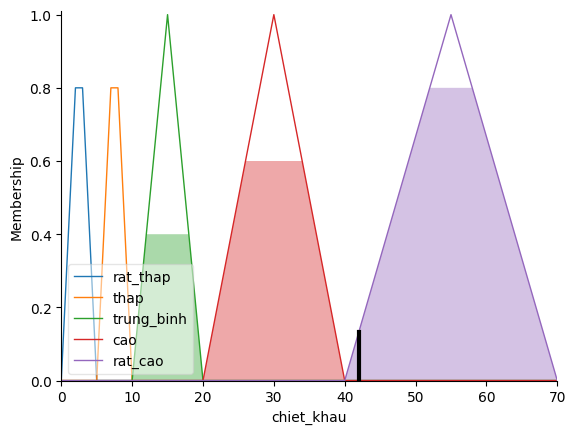

In [ ]:
rule1 = ctrl.Rule(xep_hang['high'] & khoi_luong_sale['high'] & bien_loi_nhuan['high'], chiet_khau['rat_thap'])
rule2 = ctrl.Rule(xep_hang['low'] & khoi_luong_sale['low'] & bien_loi_nhuan['high'], chiet_khau['cao'])
rule3 = ctrl.Rule(theo_mua['high'] & doi_thu['high'], chiet_khau['rat_cao'])
rule4 = ctrl.Rule(xep_hang['med'] & khoi_luong_sale['med'] & bien_loi_nhuan['med'], chiet_khau['trung_binh'])
rule5 = ctrl.Rule(doi_thu['low'] & bien_loi_nhuan['low'] & khoi_luong_sale['high'], chiet_khau['rat_thap'])
rule6 = ctrl.Rule(xep_hang['low'] & theo_mua['none'], chiet_khau['trung_binh'])
rule7 = ctrl.Rule(khoi_luong_sale['low'] & bien_loi_nhuan['low'], chiet_khau['rat_thap'])
rule_8 = ctrl.Rule(theo_mua['high'] & doi_thu['high'] & bien_loi_nhuan['low'], chiet_khau['cao'])

he_thong_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule_8])
simulation = ctrl.ControlSystemSimulation(he_thong_ctrl)

simulation.input['xep_hang'] = 4.3
simulation.input['khoi_luong_sale'] = 5
simulation.input['bien_loi_nhuan'] = 2
simulation.input['theo_mua'] = 9
simulation.input['doi_thu'] = 9


simulation.compute()
ket_qua = simulation.output['chiet_khau']
print(f"Mức chiết khấu đề xuất từ AI: {ket_qua:.2f}%")
chiet_khau.view(sim=simulation)

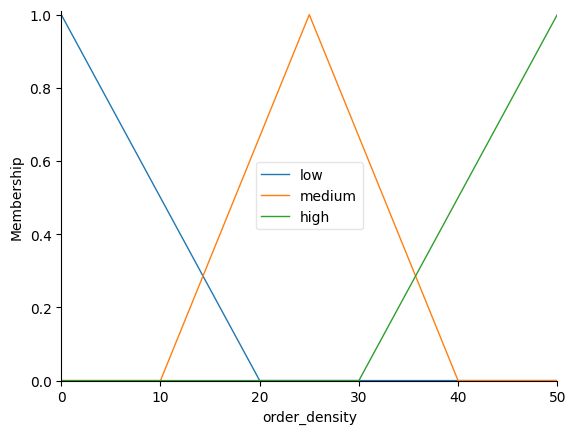

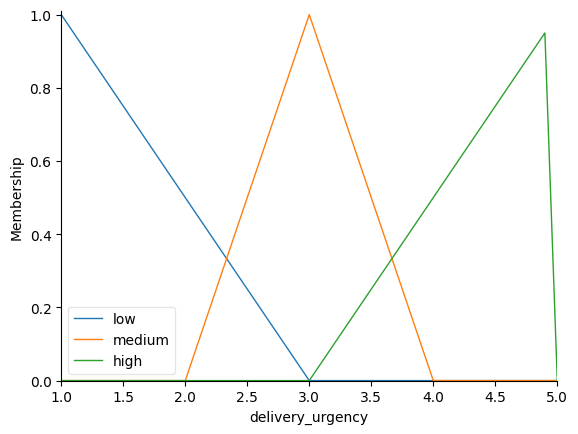

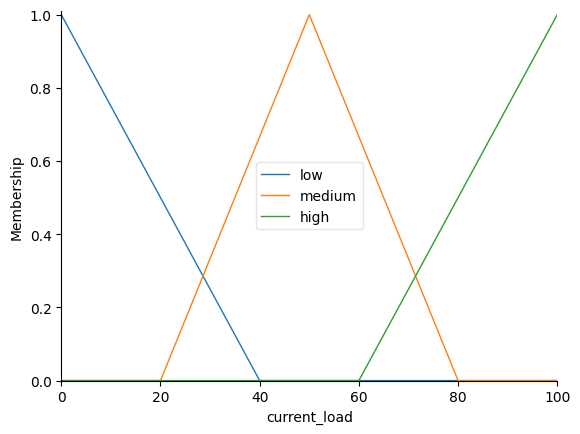

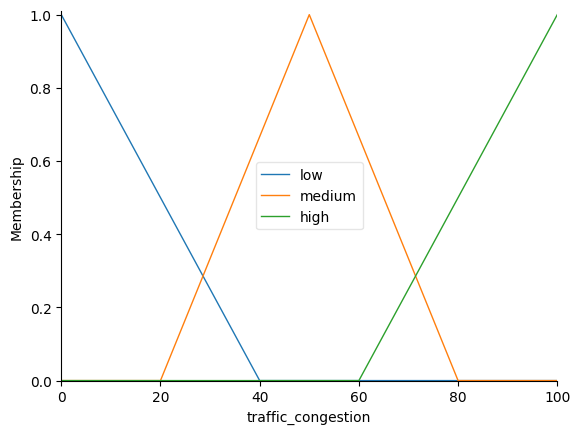

In [3]:
#2.14
!pip install scikit-fuzzy
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

order_density = ctrl.Antecedent(np.arange(0, 51, 1), 'order_density')
delivery_urgency = ctrl.Antecedent(np.arange(1, 5.1, 0.1), 'delivery_urgency')
current_load = ctrl.Antecedent(np.arange(0, 101, 1), 'current_load')
traffic_congestion = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic_congestion')
profit_per_delivery = ctrl.Antecedent(np.arange(10, 101, 1), 'profit_per_delivery')
orders_to_combine = ctrl.Consequent(np.arange(1, 21, 1), 'orders_to_combine')
delivery_priority = ctrl.Consequent(np.arange(0, 10.1, 0.1), 'delivery_priority')

order_density['low'] = fuzz.trimf(order_density.universe, [0, 0, 20])
order_density['medium'] = fuzz.trimf(order_density.universe, [10, 25, 40])
order_density['high'] = fuzz.trimf(order_density.universe, [30, 50, 50])

delivery_urgency['low'] = fuzz.trimf(delivery_urgency.universe, [1, 1, 3])
delivery_urgency['medium'] = fuzz.trimf(delivery_urgency.universe, [2, 3, 4])
delivery_urgency['high'] = fuzz.trimf(delivery_urgency.universe, [3, 5, 5])

current_load['low'] = fuzz.trimf(current_load.universe, [0, 0, 40])
current_load['medium'] = fuzz.trimf(current_load.universe, [20, 50, 80])
current_load['high'] = fuzz.trimf(current_load.universe, [60, 100, 100])

traffic_congestion['low'] = fuzz.trimf(traffic_congestion.universe, [0, 0, 40])
traffic_congestion['medium'] = fuzz.trimf(traffic_congestion.universe, [20, 50, 80])
traffic_congestion['high'] = fuzz.trimf(traffic_congestion.universe, [60, 100, 100])

profit_per_delivery['low'] = fuzz.trimf(profit_per_delivery.universe, [10, 10, 40])
profit_per_delivery['medium'] = fuzz.trimf(profit_per_delivery.universe, [30, 55, 80])
profit_per_delivery['high'] = fuzz.trimf(profit_per_delivery.universe, [60, 100, 100])

orders_to_combine['few'] = fuzz.trimf(orders_to_combine.universe, [1, 1, 6])
orders_to_combine['some'] = fuzz.trimf(orders_to_combine.universe, [4, 8, 12])
orders_to_combine['many'] = fuzz.trimf(orders_to_combine.universe, [10, 20, 20])

delivery_priority['low'] = fuzz.trimf(delivery_priority.universe, [0, 0, 4])
delivery_priority['medium'] = fuzz.trimf(delivery_priority.universe, [3, 5, 7])
delivery_priority['high'] = fuzz.trimf(delivery_priority.universe, [6, 10, 10])

order_density.view()
delivery_urgency.view()
current_load.view()
traffic_congestion.view()


Số lượng đơn hàng nên kết hợp: ~16 đơn
Mức độ ưu tiên giao nhóm này (0-10): 5.0/10


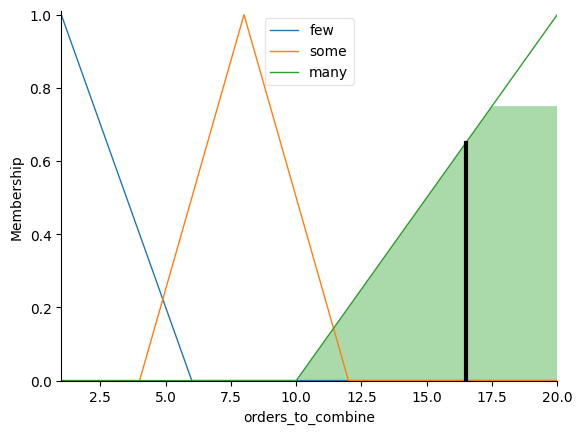

In [4]:
rule1 = ctrl.Rule(order_density['high'] & current_load['low'] & traffic_congestion['low'], orders_to_combine['many'])
rule2 = ctrl.Rule(order_density['medium'] & traffic_congestion['high'] & delivery_urgency['medium'], orders_to_combine['some'])
rule3 = ctrl.Rule(current_load['high'] & order_density['high'] & profit_per_delivery['medium'], orders_to_combine['some'])
rule4 = ctrl.Rule(order_density['low'] & delivery_urgency['high'] & traffic_congestion['medium'], orders_to_combine['some'])
rule5 = ctrl.Rule(profit_per_delivery['high'] & delivery_urgency['high'] & traffic_congestion['high'], orders_to_combine['some'])
rule6 = ctrl.Rule(delivery_urgency['high'] & profit_per_delivery['high'], delivery_priority['high'])
rule7 = ctrl.Rule(delivery_urgency['medium'] & traffic_congestion['medium'], delivery_priority['medium'])
rule8 = ctrl.Rule(delivery_urgency['low'] & order_density['high'] & profit_per_delivery['low'], delivery_priority['low'])
rule9 = ctrl.Rule(order_density['high'] & current_load['low'] & traffic_congestion['medium'], orders_to_combine['many'])

logistics_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])
simulation = ctrl.ControlSystemSimulation(logistics_ctrl)

simulation.input['order_density'] = 45
simulation.input['delivery_urgency'] = 3
simulation.input['current_load'] = 10
simulation.input['traffic_congestion'] = 50
simulation.input['profit_per_delivery'] = 55

simulation.compute()
ket_qua_don = simulation.output['orders_to_combine']
ket_qua_uu_tien = simulation.output['delivery_priority']

print(f"Số lượng đơn hàng nên kết hợp: ~{ket_qua_don:.0f} đơn")
print(f"Mức độ ưu tiên giao nhóm này (0-10): {ket_qua_uu_tien:.1f}/10")

orders_to_combine.view(sim=simulation)